Mean Squared Error: 1606443846.1805131
R2 Score: 0.7905638166111802
     Id      SalePrice
0  1461  120249.530864
1  1462  155633.518163
2  1463  174134.823861
3  1464  195074.026303
4  1465  202500.473183


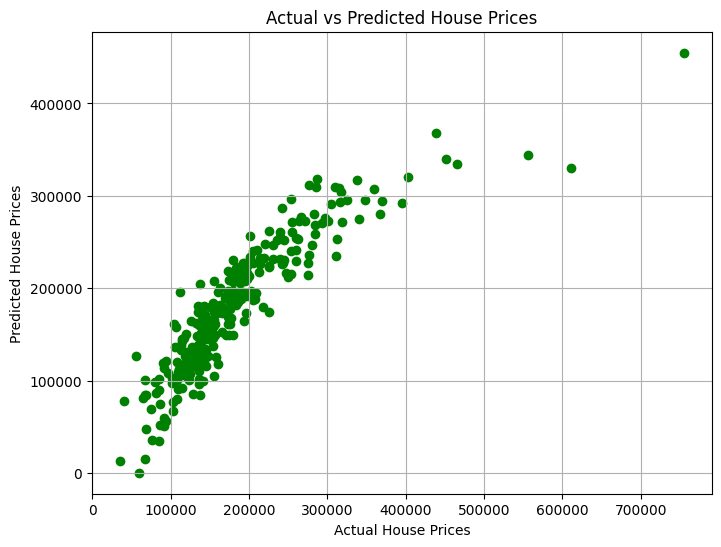

Graph saved successfully.


In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load datasets
train_data = pd.read_csv('train.csv')
test_data = pd.read_csv('test.csv')

# Selected features
selected_features = [
    'MSSubClass',
    'LotArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'GrLivArea',
    'GarageCars',
    'GarageArea',
    'FullBath',
    'HalfBath',
    'TotRmsAbvGrd',
    'YearRemodAdd'
]

# Features and target
X = train_data[selected_features]
y = train_data['SalePrice']

# Handle missing values
imputer = SimpleImputer(strategy='mean')

X_imputed = imputer.fit_transform(X)

# Split data
X_train, X_valid, y_train, y_valid = train_test_split(
    X_imputed,
    y,
    test_size=0.2,
    random_state=42
)

# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

# Predict validation data
y_pred_valid = model.predict(X_valid)

# Accuracy metrics
mse = mean_squared_error(y_valid, y_pred_valid)

r2 = r2_score(y_valid, y_pred_valid)

print("Mean Squared Error:", mse)

print("R2 Score:", r2)

# Predict test dataset
X_test = test_data[selected_features]

X_test_imputed = imputer.transform(X_test)

test_predictions = model.predict(X_test_imputed)

# Create submission file
submission = pd.DataFrame({
    'Id': test_data['Id'],
    'SalePrice': test_predictions
})

# Save CSV
submission.to_csv(
    'house_price_submission.csv',
    index=False
)

print(submission.head())

# Graph Visualization
plt.figure(figsize=(8, 6))

plt.scatter(
    y_valid,
    y_pred_valid,
    color='green'
)

plt.xlabel('Actual House Prices')

plt.ylabel('Predicted House Prices')

plt.title('Actual vs Predicted House Prices')

plt.grid(True)

# Save graph
plt.savefig('house_price_graph.png')

plt.show()

print("Graph saved successfully.")